# Unified Geophysical Workflow

This notebook runs a complete ERT workflow, from inversion to water content with uncertainty, from a request written in plain language through `BaseAgent.run_unified_agent_workflow()`.

## How It Works

```python
# 1. Describe the task in plain language
user_request = "We have ERT data from a DAS-1 instrument at ..."

# 2. A language model turns the request into a workflow configuration
config = context_agent.parse_request(user_request)
config["user_request"] = user_request   # the controller reads the request too

# 3. The workflow controller runs it, choosing each step from what the run holds
results, plan, interpretation, files = BaseAgent.run_unified_agent_workflow(
    config, api_key, llm_model, llm_provider, output_dir
)

# 4. Results, the steps that ran, an interpretation and the report files
```

`run_unified_agent_workflow()` hands the configuration to the workflow controller in `PyHydroGeophysX.agents.runtime`. Before each step the controller lists the tools whose inputs the run already holds (load the surveys, invert them, evaluate the inversion, convert to water content, fetch climate data, invert a seismic line, derive structural constraints, fuse methods, write the report), picks one, and reads its result before picking the next. With an API key the language model picks; without one, the controller takes the runnable tools in dependency order. The execution plan it returns lists the steps that ran, each with the reason it was chosen.

The companion notebooks send other requests through the same call: a time-lapse survey with climate data (`Ex_Unified_Workflow_ex2`) and a seismic line that constrains an ERT inversion (`Ex_Unified_Workflow_ex3`).

---

## 1. Setup and Imports

In [1]:
import json
import os
from pathlib import Path

import numpy as np

from PyHydroGeophysX.agents import BaseAgent, ContextInputAgent

# Where this notebook writes its results
default_output_dir = Path('results/unified_workflow')
default_output_dir.mkdir(parents=True, exist_ok=True)

print("✓ PyHydroGeophysX agents imported")
print(f"✓ Output directory: {default_output_dir}")

✓ PyHydroGeophysX agents imported
✓ Output directory: results\unified_workflow


## 2. Configure the Language Model

The request is parsed by a language model. Set `OPENAI_API_KEY` to parse it live. Without a key the notebook uses the configuration the parser produced for this request in the reference run, so it still runs, on the same configuration as the reference run; the workflow controller then takes the runnable steps in dependency order instead of asking the model.

In [2]:
# Configure API (set OPENAI_API_KEY in the environment, or change the provider)
llm_provider = 'openai'  # Options: 'openai', 'gemini', 'claude'
llm_model = 'gpt-4o-mini'
api_key = os.getenv('OPENAI_API_KEY')

if api_key:
    # Natural-language parsing of the request
    context_agent = ContextInputAgent(api_key=api_key, model=llm_model, llm_provider=llm_provider)
    print(f"✓ Using {llm_provider} with model {llm_model}")
else:
    context_agent = None
    print("ℹ️  No API key: the notebook uses the recorded configuration, and the")
    print("   workflow controller takes the runnable steps in dependency order")

ℹ️  No API key: the notebook uses the recorded configuration, and the
   workflow controller takes the runnable steps in dependency order


## 3. Example: ERT to Water Content

A DAS-1 survey from the Snowy Range, Wyoming, with the petrophysical parameters stated in the request. The controller loads and inverts the survey, evaluates the inversion, converts the model to water content with Monte Carlo uncertainty, and writes a report.

In [3]:
user_request = """We have ERT data from DAS-1 instrument at examples/data/ERT/DAS/20171105_1418.Data 
and electrode file in examples/data/ERT/DAS/electrodes.dat 
in the Snowy Range in southeastern Wyoming. The bedrock consists of foliated gneiss in the Cheyenne Belt. 
Use specific petrophysical parameters: rho_sat = 541, porosity = 0.37, n = 1.24"""

# The configuration the parser produced for this request in the reference run.
# It is used when no API key is set, so the notebook still runs on that configuration.
RECORDED_CONFIG = json.loads(r"""
{
  "data_file": "examples/data/ERT/DAS/20171105_1418.Data",
  "project_dir": "examples/data/ERT/DAS",
  "instrument": "DAS-1",
  "crs": "local",
  "inversion_mode": "standard",
  "inversion_params": {
    "lambda": 15,
    "max_iterations": 10,
    "method": "cgls",
    "use_gpu": false
  },
  "petrophysical_parameters": {
    "rho_sat": 541,
    "porosity": 0.37,
    "n": 1.24
  },
  "fusion_pattern": null,
  "methods": [
    "ert"
  ],
  "ert_file": "examples/data/ERT/DAS/20171105_1418.Data",
  "ert_params": {
    "lambda": null,
    "max_iterations": 20,
    "limits": [
      null,
      null
    ]
  },
  "n_realizations": 100,
  "layer_params": {
    "regolith": {
      "rho_sat_range": [
        541,
        541
      ],
      "n_range": [
        1.24,
        1.24
      ],
      "porosity_range": [
        0.37,
        0.37
      ]
    }
  },
  "output_dir": null,
  "coverage_threshold": -1.0,
  "use_climate": false,
  "petrophysical_params": {
    "rho_sat": 541.0,
    "porosity": 0.37,
    "n": 1.24
  },
  "electrode_file": "examples/data/ERT/DAS/electrodes.dat",
  "use_seismic": false,
  "run_uncertainty": true
}
""")

print("=" * 70)
print("USER REQUEST:")
print(user_request)
print("=" * 70)

if context_agent is not None:
    print("\n🤖 Parsing request...")
    config = context_agent.parse_request(user_request)
else:
    config = json.loads(json.dumps(RECORDED_CONFIG))   # a fresh copy
    print("\nℹ️  Using the recorded configuration")
# The controller reads the request too: what it asks for, and the report quotes it
config["user_request"] = user_request
print(json.dumps({key: value for key, value in config.items() if key != "user_request"},
                 indent=2, default=str))

# The workflow controller chooses each step from the tools whose inputs exist
print("\n🚀 Running the workflow...")
output_dir = Path('results/unified_workflow/example_1')
results, execution_plan, interpretation, report_files = BaseAgent.run_unified_agent_workflow(
    config, api_key, llm_model, llm_provider, output_dir
)

USER REQUEST:
We have ERT data from DAS-1 instrument at examples/data/ERT/DAS/20171105_1418.Data 
and electrode file in examples/data/ERT/DAS/electrodes.dat 
in the Snowy Range in southeastern Wyoming. The bedrock consists of foliated gneiss in the Cheyenne Belt. 
Use specific petrophysical parameters: rho_sat = 541, porosity = 0.37, n = 1.24

ℹ️  Using the recorded configuration
{
  "data_file": "examples/data/ERT/DAS/20171105_1418.Data",
  "project_dir": "examples/data/ERT/DAS",
  "instrument": "DAS-1",
  "crs": "local",
  "inversion_mode": "standard",
  "inversion_params": {
    "lambda": 15,
    "max_iterations": 10,
    "method": "cgls",
    "use_gpu": false
  },
  "petrophysical_parameters": {
    "rho_sat": 541,
    "porosity": 0.37,
    "n": 1.24
  },
  "fusion_pattern": null,
  "methods": [
    "ert"
  ],
  "ert_file": "examples/data/ERT/DAS/20171105_1418.Data",
  "ert_params": {
    "lambda": null,
    "max_iterations": 20,
    "limits": [
      null,
      null
    ]
  },
  

[PyHydroGeophysX] ResIPy is not installed; using this package's own readers. Install with: pip install "PyHydroGeophysX[ert]"
[PyHydroGeophysX] PyGIMLi loaded successfully


[PyHydroGeophysX] SimPEG loaded successfully (version 0.25.2)
[PyHydroGeophysX] Reading ERT data without ResIPy.
ResIPy is the recommended ERT reader: it covers more instrument formats than this package reads on its own.
    pip install "PyHydroGeophysX[ert]"        (or: pip install resipy)

If the install or the import fails:
  * a compiler or build error: ResIPy carries compiled solvers, and a cloud image or slim container often has no toolchain. Try 'pip install --only-binary :all: resipy', or build the environment from conda-forge.
  * an import error after a successful install: usually a NumPy or Python version mismatch. 'pip check' names the conflict.
  * no network: install it into the image ahead of time; the readers below need nothing extra and will keep working meanwhile.

Without ResIPy this package reads: ABEM-Lund, ARES, BERT, DAS-1, E4D, Lippmann, ResInv, Sting, Subsurface Insights. Any other format needs it.
[PyHydroGeophysX] Attempting to parse ERT data with DAS-1 parse

[ert_loader] [INFO] Loading data from data\ERT\DAS\20171105_1418.Data (DAS-1 format)
[ert_loader] [INFO] Using electrode file: data\ERT\DAS\electrodes.dat
   electrodes.dat lists the 56 electrodes this survey uses, of the 280 in the data file's table
   Updated electrode positions from electrodes.dat
   Using reciprocal-based error estimates (finite=930/945, mean: 0.0103)
[ert_loader] [INFO] Loaded 56 electrodes, 945 measurements
[ert_loader] [INFO] Running quality control checks


26/09/26 - 10:12:07 - pyGIMLi - INFO - Cache <env>\Lib\site-packages\pygimli\physics\ert\ert.py:createGeometricFactors restored (2.7s x 28): <appdata>\pygimli\Cache\14381462091403553456


...

[petrophysics] [INFO] Results saved to disk
[petrophysics] [INFO] Water content range: 0.0016 - 0.3677
[petrophysics] [INFO] Mean uncertainty: 0.0756
[data_fusion] [INFO] Starting multi-method data fusion
[data_fusion] [INFO] Using fusion pattern: petrophysics_integration
[data_fusion] [INFO] Pattern description: Convert resistivity to hydrological properties
[data_fusion] [INFO] Workflow steps: ['ert_inversion', 'petrophysics_conversion']
[data_fusion] [INFO] Execution plan created with 2 steps
[data_fusion] [INFO] Data fusion planning completed successfully
[report_generator] [INFO] Starting report generation
[report_generator] [INFO] Generating report sections
[report_generator] [INFO] Coverage threshold: 0.054 (kept 53.2% cells, deepest point 30.0 m, min target 30.0 m)
[report_generator] [INFO] Resistivity colormap: 210.2 to 21579.7 ohm-m


[report_generator] [INFO] Vertical display span set to 30.0 m (min required 30.0 m)
[report_generator] [INFO] Saved resistivity model plot


[report_generator] [INFO] Water content colormap: 0.000 to 0.195


[report_generator] [INFO] Saved water content plot
[report_generator] [INFO] Uncertainty colormap: 0.0001 to 0.1573


[report_generator] [INFO] Saved water content uncertainty plot
[report_generator] [WARNING] markdown package not installed; skipping the PDF (the Markdown report is still written)
[report_generator] [INFO] Report saved to results\unified_workflow\example_1\workflow_report.md


## 4. Results

The execution plan lists every step the controller took, with the reason it chose it, its status and its run time. The interpretation below it is the controller's own account of the run.

In [4]:
print("=" * 70)
print("STEPS THE CONTROLLER TOOK")
print("=" * 70)
for i, step in enumerate(execution_plan, 1):
    print(f"{i}. {step['step']} ({step['agent']}): {step['status']}, {step['seconds']:.0f} s")
    print(f"   why: {step['reason']}")

print(f"\nStatus: {results.get('status')}")
for warning in results.get('warnings', []):
    print(f"  ! {warning}")

evaluation = results.get('evaluation_results') or {}
fit = (evaluation.get('quality_metrics') or {}).get('data_fit') or {}
if fit.get('final_chi2') is not None:
    print(f"\nData fit: chi² = {fit['final_chi2']:.2f} (target 1)")

wc = results.get('water_content_mean')
if wc is not None:
    wc, wc_std = np.asarray(wc, dtype=float), np.asarray(results.get('water_content_std'), dtype=float)
    print(f"Water content: {np.nanmin(wc):.3f} to {np.nanmax(wc):.3f}, "
          f"mean {np.nanmean(wc):.3f} ± {np.nanmean(wc_std):.3f}")

if report_files:
    print(f"\n📄 Report files:")
    for name, path in report_files.items():
        print(f"  - {name}: {path}")

print("\n" + "=" * 70)
print("INTERPRETATION")
print("=" * 70)
print(interpretation)

STEPS THE CONTROLLER TOOK
1. Load ERT data (ERTLoaderAgent): ok, 2 s
   why: next available step
2. Run ERT inversion (ERTInversionAgent): ok, 25 s
   why: next available step
3. Evaluate inversion quality (InversionEvaluationAgent): ok, 82 s
   why: next available step
4. Convert to water content (PetrophysicsAgent): ok, 0 s
   why: next available step
5. Fuse methods (DataFusionAgent): ok, 0 s
   why: next available step
6. Generate report (ReportAgent): ok, 1 s
   why: next available step

Status: success
  ! The exported model carries no layer markers: The cell markers do not describe geological structure (1173 markers for 1173 cells), so the section is treated as a single unit with one petrophysical parameter set. Supplying a layered model is what would let parameters vary with depth.
  ! Quality optimization stopped after 3 attempts with score 29.1; one or more quality criteria were not met.
  ! Layer parameters given for regolith were not applied: this model has no structural la

### Figures

The report agent saves its figures beside the report; they are shown here.

resistivity


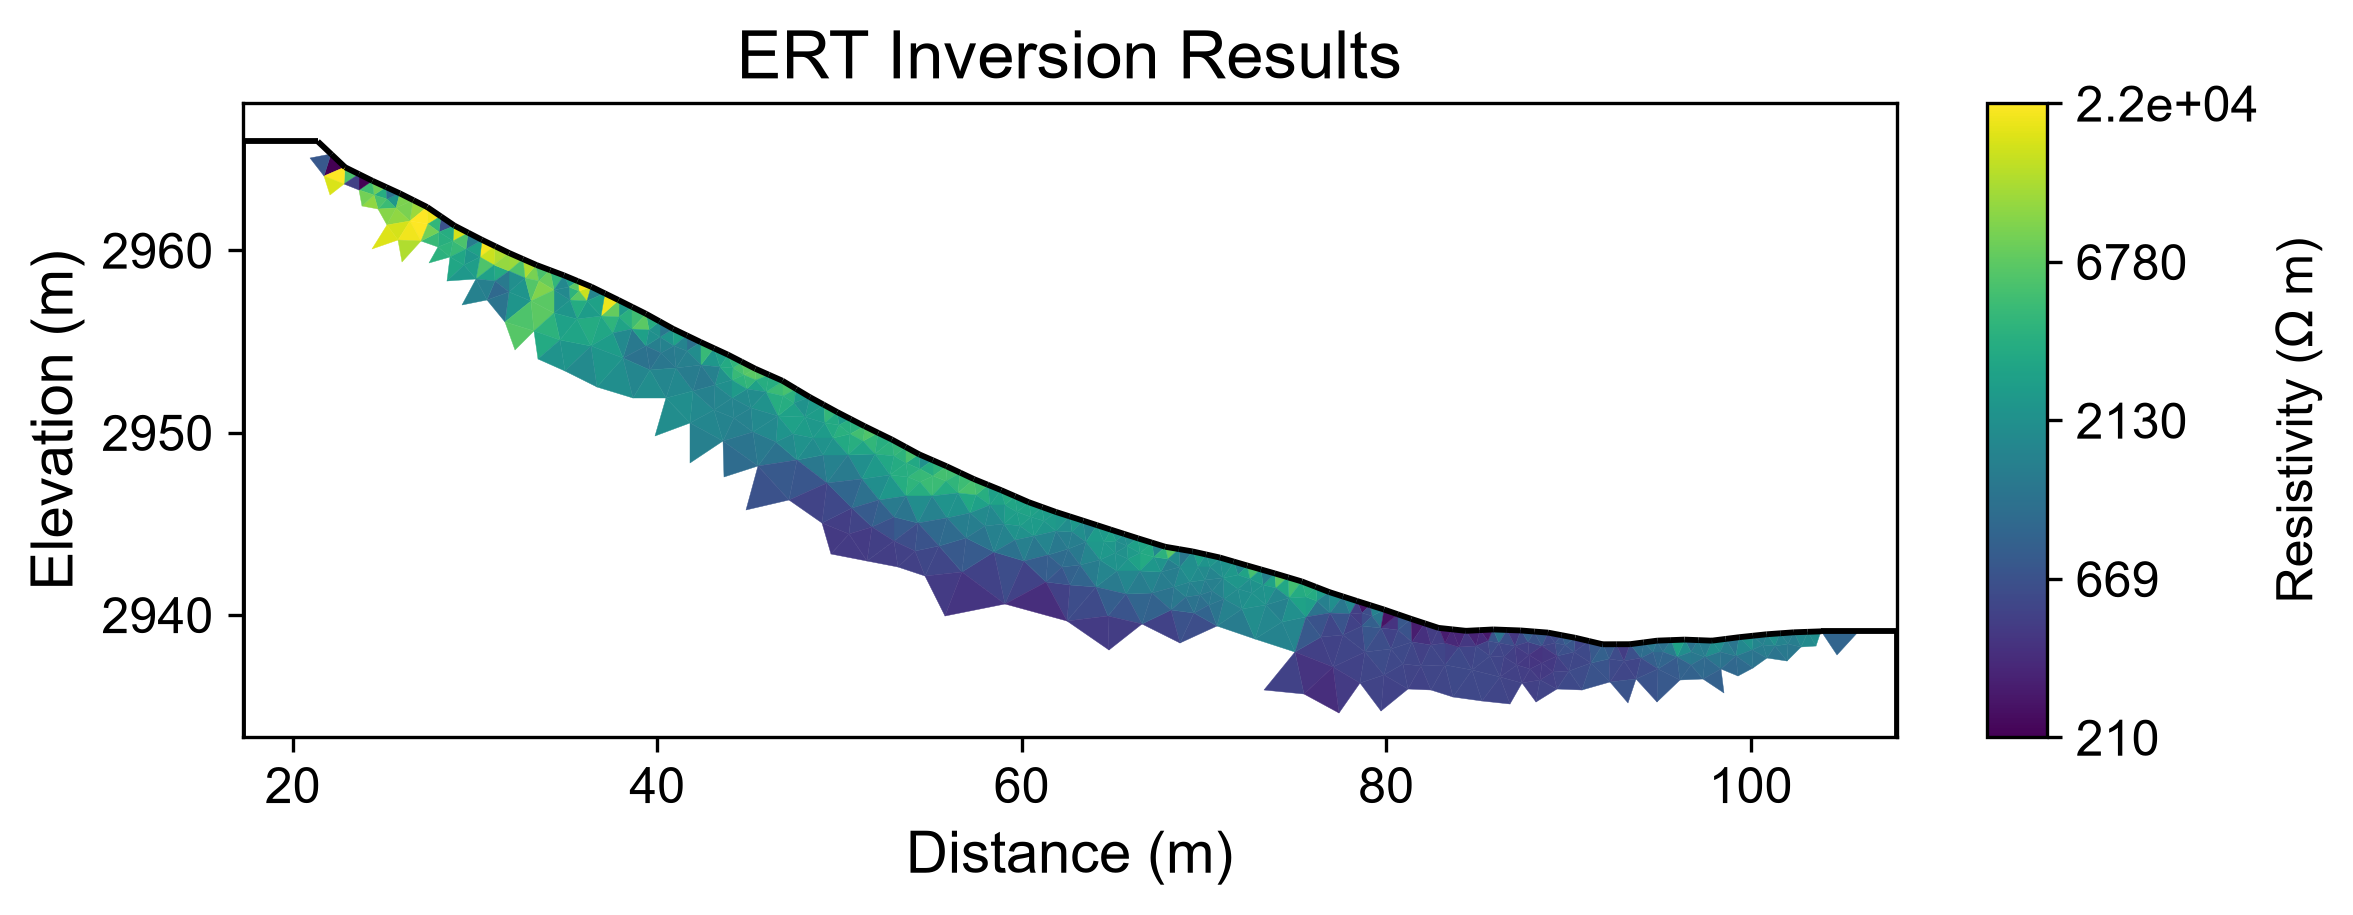

water content


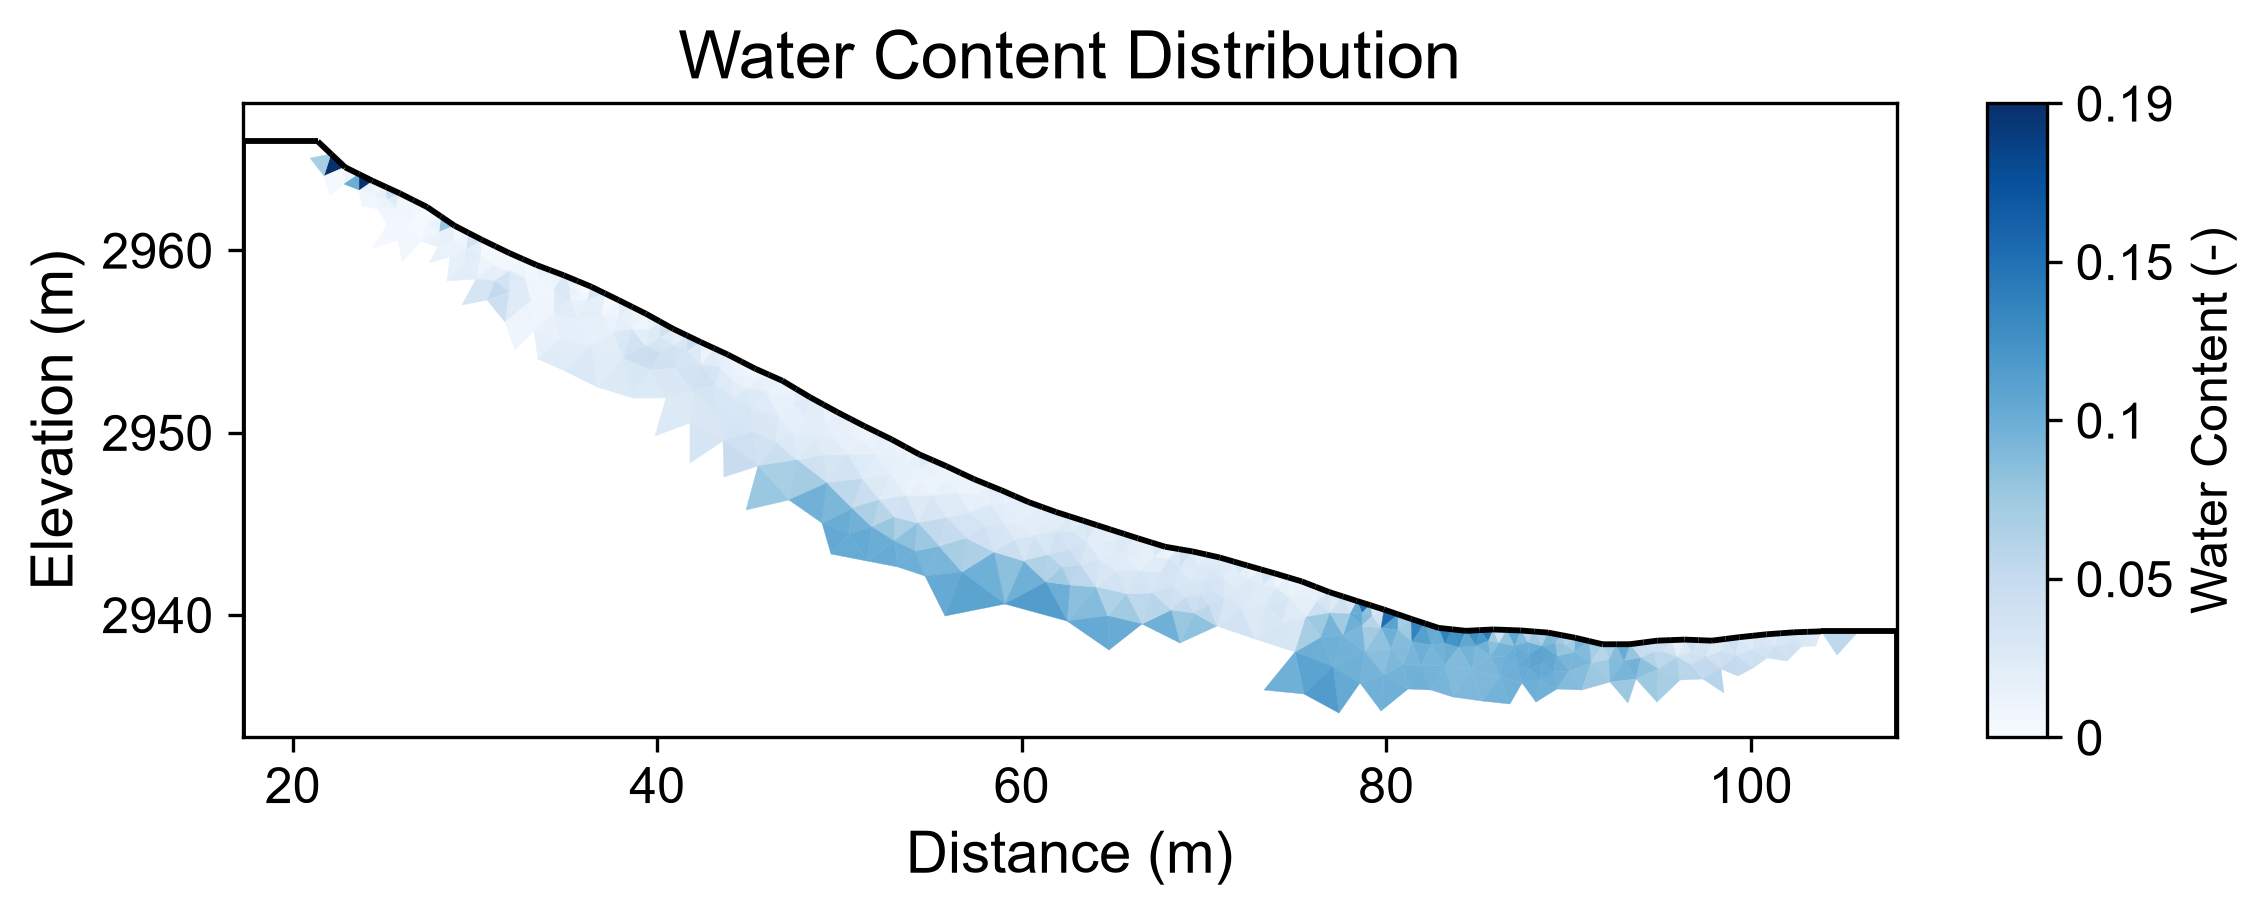

water content uncertainty


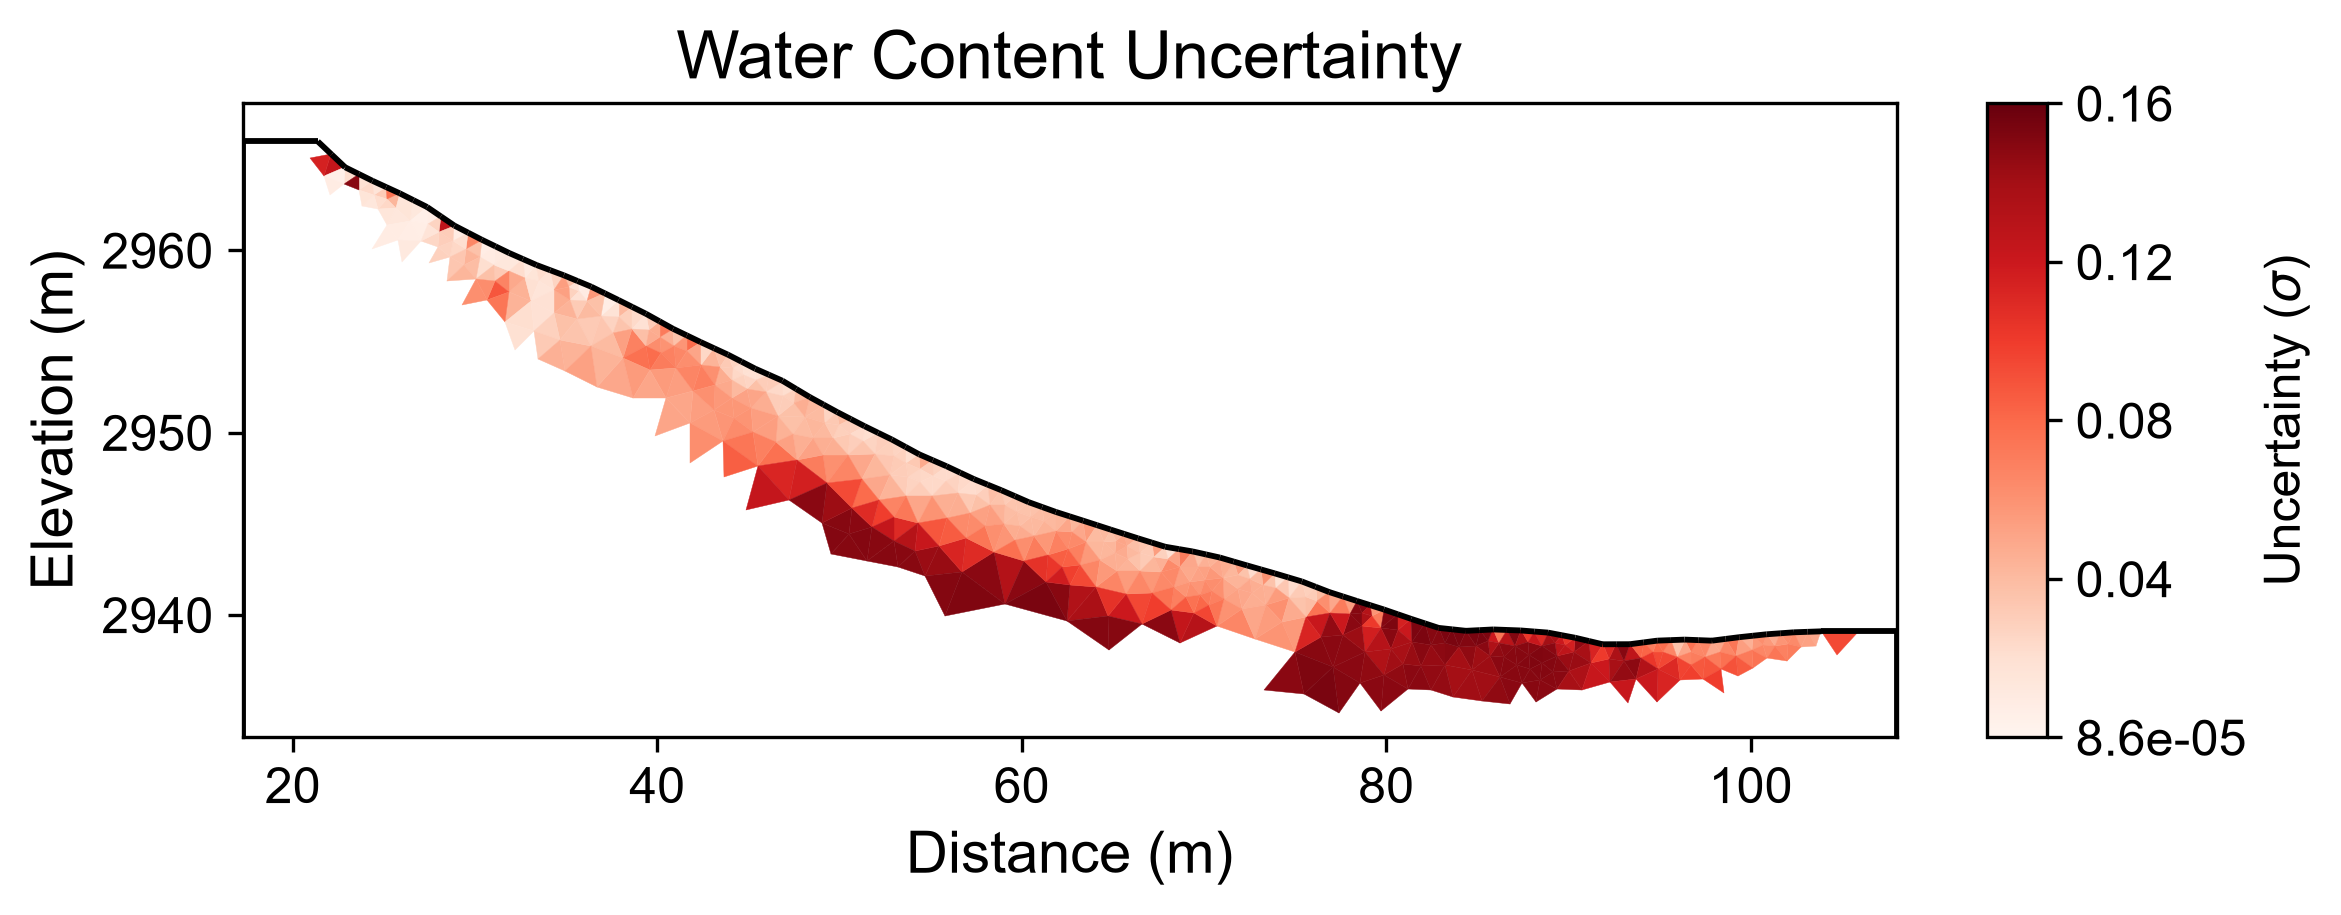

In [5]:
from IPython.display import Image, display

for name, path in (report_files or {}).items():
    if str(path).lower().endswith('.png') and Path(path).exists():
        print(name.replace('visualization_', '').replace('_', ' '))
        display(Image(filename=str(path)))

## Summary

- **One entry point**: `BaseAgent.run_unified_agent_workflow()` takes the parsed configuration of any request.
- **Steps chosen from the data**: the controller offers only the tools whose inputs exist, and the execution plan is built from the steps that ran, so it cannot list a step that did not happen.
- **Other requests, same call**: `Ex_Unified_Workflow_ex2` (time-lapse with climate data) and `Ex_Unified_Workflow_ex3` (seismic-constrained ERT with layer-specific petrophysics) change only the request.
- **Step by step**: to approve each step before it runs, pass an approval function:

```python
from PyHydroGeophysX.agents.runtime.modes import step_by_step

def approve(step):
    return 'proceed' if input(f"Run '{step['label']}'? [y/n] ") == 'y' else 'stop'

BaseAgent.run_unified_agent_workflow(config, api_key, llm_model, llm_provider, output_dir,
                                     on_step=step_by_step(approve))
```

- **The previous pipeline**: set `PHGX_LEGACY_WORKFLOW=1` to run the fixed per-type pipeline the controller replaced.

### Next: Try the Streamlit Web App

For an interface without code, check out `app_geophysics_workflow.py`, a web UI where you can:
- Input natural language descriptions
- Upload data files
- Get results and reports automatically

Run with: `streamlit run app_geophysics_workflow.py`